In [1]:
import os
from torchvision import io, utils
from pycocotools.coco import COCO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from pycocotools.cocoeval import COCOeval
from torchvision.datasets import CocoDetection
import torch
from torchvision.transforms.functional import to_tensor
import pytorch_lightning as pl
import json

import torch
import pytorch_lightning as pl
from detectron2.config import LazyConfig, instantiate
from detectron2.data.datasets import register_coco_instances
from detectron2.checkpoint import DetectionCheckpointer
from detectron2.solver import build_optimizer
import torch
from detectron2.config import LazyConfig


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# PARAMETERS
NUM_CLASSES = 8 # 7 classes + background
EPOCHS = 100
MODEL_TYPE = "rfdetr"
VERSION = "1_puro"
#CHECKPOINT = "/workspace/SVRDD_ViT_Detection/RF_DETR/output_rfdetr_final/checkpoint_best_total.pth"
CHECKPOINT = "./output_vitdet/checkpoint_best_total.pth"
EVALUATION_RESULTS_FOLDER = "./evaluation_results"


# Caminhos do dataset
ROOT_DIR = "../../SVRDD_COCO"
TRAIN_DIRECTORY = os.path.join(ROOT_DIR, "train")
VAL_DIRECTORY = os.path.join(ROOT_DIR, "valid")
TEST_DIRECTORY = os.path.join(ROOT_DIR, "test")
ANNOTATION_FILE_NAME = "_annotations.coco.json"
DETECTIONS_PATH = "detections.json"
CLASSES = {
    0: "longitudinal crack",
    1: "transverse crack",
    2: "alligator crack",
    3: "pothole",
    4: "manhole cover",
    5: "longitudinal patch",
    6: "transverse patch",
}

In [3]:
EVALUATE_DIRECTORY = TEST_DIRECTORY
CONFIG_FILE = "/home/andre/TCC/models/VitDet/detectron2/projects/ViTDet/configs/COCO/mask_rcnn_vitdet_l_100ep.py"
CHECKPOINT = "/home/andre/TCC/models/VitDet/output_vitdet/lightning_logs/version_12/checkpoints/best-epoch=92-val_loss=0.00.ckpt"
CHECKPOINT_PTH = "/home/andre/TCC/models/VitDet/output_vitdet/model_detectron2.pth"
PRETRAINED = '/home/andre/TCC/models/VitDet/output_vitdet/model_final_6146ed.pkl'

In [1]:
import torch

print("VRAM total:", torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")
print("VRAM alocada:", torch.cuda.memory_allocated(0) / 1e9, "GB")
print("VRAM cache:", torch.cuda.memory_reserved(0) / 1e9, "GB")
print("VRAM livre aproximada:", (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved(0)) / 1e9, "GB")


VRAM total: 4.294836224 GB
VRAM alocada: 0.0 GB
VRAM cache: 0.0 GB
VRAM livre aproximada: 4.294836224 GB


In [ ]:
def count_classes(coco_gt):
    # --- Contagem de instâncias ---
    cat_ids = coco_gt.getCatIds()
    cats = [coco_gt.loadCats([i])[0]["name"] for i in cat_ids]
    area_labels = ["small", "medium", "large"]

    counts_dict = {cat: {"small":0, "medium":0, "large":0} for cat in cats}
    ann_ids = coco_gt.getAnnIds()
    anns = coco_gt.loadAnns(ann_ids)

    for ann in anns:
        cat_name = coco_gt.loadCats([ann["category_id"]])[0]["name"]
        area = ann["area"]
        if area < 32**2:
            counts_dict[cat_name]["small"] += 1
        elif area < 96**2:
            counts_dict[cat_name]["medium"] += 1
        else:
            counts_dict[cat_name]["large"] += 1
    return cats, counts_dict


def evaluate_coco(dataset_dir, json_detection_path, excel_path="coco_results.xlsx"):

    GT_ANN_FILE = os.path.join(dataset_dir, ANNOTATION_FILE_NAME)

    # carregar ground truth
    coco_gt = COCO(GT_ANN_FILE)

    # carregar detecções
    coco_dt = coco_gt.loadRes(json_detection_path)

    # rodar avaliação
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    # métricas por classe
    cats, counts_dict = count_classes(coco_gt)

    # Converter para DataFrame
    df_counts = pd.DataFrame(counts_dict).T
    df_counts["total"] = df_counts.sum(axis=1)
    df_counts = df_counts[["total", "small", "medium", "large"]]
    print("\n=== Contagem de instâncias por classe e tamanho ===")
    print(df_counts)

    # --- Tabelas de métricas ---
    precisions = coco_eval.eval['precision']  # [TxRxKxAxM]
    iou_thrs = coco_eval.params.iouThrs
    iou50_idx = np.where(iou_thrs == 0.5)[0][0]
    maxDets_idx = 2  # normalmente corresponde a 100 maxDets
    area_labels_full = ["all", "small", "medium", "large"]
    metrics_tables = {}
    
    for a_idx, area in enumerate(area_labels_full):
        data = []
        for idx, cat in enumerate(cats):
            # mAP 0.50:0.95
            precision_all = precisions[:, :, idx, a_idx, maxDets_idx]
            precision_all = precision_all[precision_all > -1]
            mAP = np.mean(precision_all) if precision_all.size > 0 else np.nan

            # mAP50
            precision50 = precisions[iou50_idx, :, idx, a_idx, maxDets_idx]
            precision50 = precision50[precision50 > -1]
            mAP50 = np.mean(precision50) if precision50.size > 0 else np.nan

            # quantidade
            if area == "all":
                qty = df_counts.loc[cat, "total"]
            else:
                qty = df_counts.loc[cat, area]

            data.append([qty, mAP50, mAP])

        df_metrics = pd.DataFrame(data, columns=["Quantidade", "mAP50", "mAP50:0.95"], index=cats)
        metrics_tables[area] = df_metrics
        print(f"\n=== Métricas para tamanho '{area}' ===")
        print(df_metrics.round(3))

    # --- Exportar tudo para Excel ---
    with pd.ExcelWriter(excel_path) as writer:
        df_counts.round(3).to_excel(writer, sheet_name="counts")
        for area, df in metrics_tables.items():
            df.round(3).to_excel(writer, sheet_name=area)

    print(f"\n📁 Arquivo Excel exportado com sucesso para: {excel_path}")
    return coco_eval

def get_one_example_prediction(image_id: int, results: list):
    pred_box = []
    pred_label = []
    pred_score = []
    for i in range(len(results)):
        # Pegar todas as boxes , labels e scores do resultado que tiver image_id == x
        if results[i]["image_id"] == image_id + 1:
            pred_box.append(results[i]["bbox"])
            pred_label.append(results[i]["category_id"])
            pred_score.append(results[i]["score"])
        elif results[i]["image_id"] > image_id + 1:
            break

    pred_box = torch.tensor(pred_box)
    pred_label = torch.tensor(pred_label)
    pred_score = torch.tensor(pred_score)
    return pred_box, pred_label, pred_score

def coco_load_image(img_info: dict, dataset_dir: str):
    # Getting image tensor
    img_path = os.path.join(dataset_dir, img_info["file_name"])
    image = Image.open(img_path).convert("RGB")
    img_tensor = to_tensor(image).to(device)
    return img_tensor

def get_image_and_target(image_id: int, dataset_dir: str):
    
    # Getting dataset on coco format
    coco = COCO(os.path.join(dataset_dir, ANNOTATION_FILE_NAME))

    # Getting image tensor
    coco_img_id = coco.getImgIds()[image_id]
    img_info = coco.loadImgs(coco_img_id)[0]
    img_tensor = coco_load_image(img_info, dataset_dir)

    # Getting annotation target
    ann_ids = coco.getAnnIds(imgIds=coco_img_id)
    anns = coco.loadAnns(ann_ids)
    target = {
        "boxes": torch.tensor([ann["bbox"] for ann in anns], dtype=torch.float32).to(device),
        "labels": torch.tensor([ann["category_id"] for ann in anns], dtype=torch.int64).to(device),
    }
    target["boxes"][:, 2] = target["boxes"][:, 0] + target["boxes"][:, 2]
    target["boxes"][:, 3] = target["boxes"][:, 1] + target["boxes"][:, 3]
    return img_tensor, target


# VitDet

In [31]:
from collections import OrderedDict

new_state = OrderedDict()

for k, v in state_dict.items():
    if k.startswith("model."):
        new_k = k.replace("model.", "")
        new_state[new_k] = v

# salvar no formato detectron2
torch.save({"model": new_state}, CHECKPOINT_PTH)

print("Checkpoint convertido para:", CHECKPOINT_PTH)
{"model": new_state}

Checkpoint convertido para: /home/andre/TCC/models/VitDet/output_vitdet/model_detectron2.pth


{'model': OrderedDict([('level_embed',
               tensor([[ 0.8726,  1.3120, -0.1993,  ..., -0.0265,  0.2100,  0.0251],
                       [-1.7814,  1.0444, -0.5382,  ..., -1.4520, -0.0972,  0.6434],
                       [-0.2112, -0.2924,  0.5737,  ...,  0.0822, -0.7104,  0.5754],
                       [ 1.0254, -0.7483,  0.4161,  ..., -1.1710, -0.3649, -0.0502]])),
              ('backbone.conv_encoder.conv1.weight',
               tensor([[[[ 1.3335e-02,  1.4664e-02, -1.5351e-02,  ..., -4.0896e-02,
                          -4.3034e-02, -7.0755e-02],
                         [ 4.1205e-03,  5.8477e-03,  1.4948e-02,  ...,  2.2060e-03,
                          -2.0912e-02, -3.8517e-02],
                         [ 2.2331e-02,  2.3595e-02,  1.6120e-02,  ...,  1.0281e-01,
                           6.2641e-02,  5.1977e-02],
                         ...,
                         [-9.0349e-04,  2.7767e-02, -1.0105e-02,  ..., -1.2722e-01,
                          -7.6604e-02,  

In [9]:
clean_state

{'model.level_embed': tensor([[ 0.8726,  1.3120, -0.1993,  ..., -0.0265,  0.2100,  0.0251],
         [-1.7814,  1.0444, -0.5382,  ..., -1.4520, -0.0972,  0.6434],
         [-0.2112, -0.2924,  0.5737,  ...,  0.0822, -0.7104,  0.5754],
         [ 1.0254, -0.7483,  0.4161,  ..., -1.1710, -0.3649, -0.0502]],
        device='cuda:0'),
 'model.backbone.conv_encoder.model.conv1.weight': tensor([[[[ 1.3335e-02,  1.4664e-02, -1.5351e-02,  ..., -4.0896e-02,
            -4.3034e-02, -7.0755e-02],
           [ 4.1205e-03,  5.8477e-03,  1.4948e-02,  ...,  2.2060e-03,
            -2.0912e-02, -3.8517e-02],
           [ 2.2331e-02,  2.3595e-02,  1.6120e-02,  ...,  1.0281e-01,
             6.2641e-02,  5.1977e-02],
           ...,
           [-9.0349e-04,  2.7767e-02, -1.0105e-02,  ..., -1.2722e-01,
            -7.6604e-02,  7.8453e-03],
           [ 3.5894e-03,  4.8006e-02,  6.2051e-02,  ...,  2.4267e-02,
            -3.3662e-02, -1.5709e-02],
           [-8.0029e-02, -3.2238e-02, -1.7808e-02,  ..., 

In [10]:
image_id = 50

# Getting image and labels from dataset
eval_dataset = XYXYDatasetFromCOCO(EVALUATE_DIRECTORY)
image_tensor, target = eval_dataset[image_id]

inputs = [{
    "image": image_tensor,
    "height": image_tensor.shape[1],
    "width": image_tensor.shape[2]
}]

# Instantiating model
print("Instantiating model...")
cfg = LazyConfig.load(CONFIG_FILE)
cfg.train.init_checkpoint = CHECKPOINT_PTH
cfg.model.roi_heads.num_classes = NUM_CLASSES - 1
model = instantiate(cfg.model)

state_dict = torch.load(CHECKPOINT)["state_dict"]
clean_state = {k.replace("model.", "", 1): v for k, v in state_dict.items()}

DetectionCheckpointer(model).load(cfg.train.init_checkpoint)
#model.load_state_dict(clean_state, strict=False)
model.to(device)

# ------ forward ------
print("Predicting...")
model.eval()
with torch.no_grad():
    outputs = model(inputs)

# Process predictions
instances = outputs[0]["instances"].to("cpu")
boxes = instances.pred_boxes.tensor.numpy()
scores = instances.scores.numpy()
classes = instances.pred_classes.numpy()

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Instantiating model...


Some model parameters or buffers are not found in the checkpoint:
backbone.net.blocks.0.attn.proj.{bias, weight}
backbone.net.blocks.0.attn.qkv.{bias, weight}
backbone.net.blocks.0.attn.{rel_pos_h, rel_pos_w}
backbone.net.blocks.0.mlp.fc1.{bias, weight}
backbone.net.blocks.0.mlp.fc2.{bias, weight}
backbone.net.blocks.0.norm1.{bias, weight}
backbone.net.blocks.0.norm2.{bias, weight}
backbone.net.blocks.1.attn.proj.{bias, weight}
backbone.net.blocks.1.attn.qkv.{bias, weight}
backbone.net.blocks.1.attn.{rel_pos_h, rel_pos_w}
backbone.net.blocks.1.mlp.fc1.{bias, weight}
backbone.net.blocks.1.mlp.fc2.{bias, weight}
backbone.net.blocks.1.norm1.{bias, weight}
backbone.net.blocks.1.norm2.{bias, weight}
backbone.net.blocks.10.attn.proj.{bias, weight}
backbone.net.blocks.10.attn.qkv.{bias, weight}
backbone.net.blocks.10.attn.{rel_pos_h, rel_pos_w}
backbone.net.blocks.10.mlp.fc1.{bias, weight}
backbone.net.blocks.10.mlp.fc2.{bias, weight}
backbone.net.blocks.10.norm1.{bias, weight}
backbone.net.b

Predicting...


In [6]:
outputs[0]['instances'].to("cpu").scores.numpy()

array([0.14378515, 0.14193718, 0.14188802, 0.14182888, 0.1417434 ,
       0.14172505, 0.14149615, 0.14149019, 0.14141789, 0.14140819,
       0.14099987, 0.1408113 , 0.14072594, 0.14068249, 0.14067891,
       0.1406666 , 0.1406655 , 0.14065807, 0.14065161, 0.140646  ,
       0.14063881, 0.14063458, 0.1406273 , 0.14062728, 0.14062063,
       0.14061743, 0.14061691, 0.14060514, 0.1405972 , 0.14059715,
       0.14058049, 0.14057766, 0.14056602, 0.14054799, 0.14054461,
       0.14054276, 0.14053477, 0.14052947, 0.14052741, 0.14052726,
       0.1405233 , 0.1405232 , 0.140521  , 0.14051078, 0.1405057 ,
       0.14050144, 0.14049459, 0.14049411, 0.14049114, 0.14049058,
       0.14048648, 0.1404826 , 0.14048044, 0.14047934, 0.14047636,
       0.14047565, 0.1404732 , 0.14047197, 0.14047004, 0.14046836,
       0.14046589, 0.14045782, 0.14045481, 0.14045106, 0.14044936,
       0.14044845, 0.14044032, 0.14043884, 0.14043868, 0.14043626,
       0.14043537, 0.14043494, 0.1404348 , 0.14043248, 0.14043

Visualizing Prediction...
Visualizing GroundTruth...


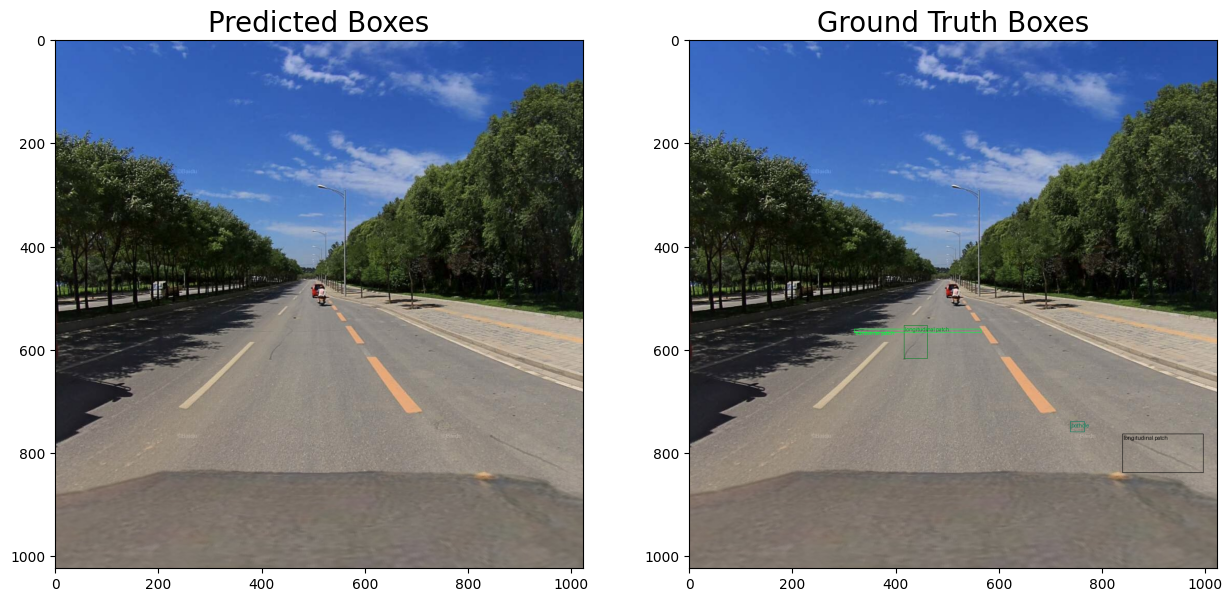

In [12]:
threshold = 0.1

# Adjust to best threshold
keep = scores >= threshold
boxes = boxes[keep]
labels = classes[keep]
scores = scores[keep]
# Convert boxes from COCO format [x, y, w, h] to xyxy [xmin, ymin, xmax, ymax]
boxes[:, 2] = boxes[:, 0] + boxes[:, 2]
boxes[:, 3] = boxes[:, 1] + boxes[:, 3]

print("Visualizing Prediction...")
# Visualize predictions.
image_with_boxes = utils.draw_bounding_boxes(
    image=(image_tensor * 255).to(torch.uint8),
    boxes=boxes,
    labels=[f"{CLASSES[label.item()]} {score:.3f}" for label, score in zip(labels, scores)],
)

fig, ax = plt.subplots(1, 2, figsize=(15, 15))
ax[0].imshow(image_with_boxes.permute(1, 2, 0))

print("Visualizing GroundTruth...")
# Visualize predictions.
image_with_boxes = utils.draw_bounding_boxes(
    image=(image_tensor * 255).to(torch.uint8),
    boxes=target["boxes"],
    labels=[f"{CLASSES[label.item()]}" for label in target["labels"]],
)

# Colocar título nas imagens
ax[0].set_title("Predicted Boxes", fontsize=20)
ax[1].set_title("Ground Truth Boxes", fontsize=20)
ax[1].imshow(image_with_boxes.permute(1, 2, 0))
fig.savefig("pred_ground_truth.png")
plt.show()

In [7]:
EVALUATE_DIRECTORY = TEST_DIRECTORY
CONFIG_FILE = "/home/andre/TCC/models/VitDet/detectron2/projects/ViTDet/configs/COCO/mask_rcnn_vitdet_l_100ep.py"
CHECKPOINT = "/home/andre/TCC/models/VitDet/output_vitdet/model_detectron2.ckpt"
PRETRAINED = '/home/andre/TCC/models/VitDet/output_vitdet/model_final_6146ed.pkl'

# Instantiating model
print("Instantiating model...")
cfg = LazyConfig.load(CONFIG_FILE)
cfg.train.init_checkpoint = PRETRAINED
cfg.model.roi_heads.num_classes = NUM_CLASSES - 1
model = instantiate(cfg.model)
state_dict = torch.load(CHECKPOINT)["state_dict"]
model.load_state_dict(state_dict, strict=False)
model.to(device)

print("Loading Dataset on COCO format...")
eval_dataset = XYXYDatasetFromCOCO(EVALUATE_DIRECTORY)

# Model Inference
model.eval()
results = []
for img_id, (img, target) in enumerate(tqdm(eval_dataset, desc="Predicting on Dataset...")):

    # formatar imagem
    img = img.to(device)

    inputs = [{
        "image": img,
        "height": img.shape[1],
        "width": img.shape[2]
    }]

    with torch.no_grad():
        outputs = model(inputs)[0]
    
    instances = outputs["instances"].to("cpu")
    boxes = instances.pred_boxes.tensor.numpy()
    scores = instances.scores.numpy()
    classes = instances.pred_classes.numpy()

    # converter boxes para formato COCO: [x, y, w, h]
    boxes[:, 2] = boxes[:, 2] - boxes[:, 0]
    boxes[:, 3] = boxes[:, 3] - boxes[:, 1]

    # montar cada previsão
    for box, score, label in zip(boxes, scores, classes):
        results.append({
            "image_id": img_id + 1,  # COCO image ids começam em 1
            "category_id": int(label),
            "bbox": box.tolist(),
            "score": float(score)
        })
        
with open(DETECTIONS_PATH, "w") as f:
    json.dump(results, f)

Instantiating model...
Loading Dataset on COCO format...
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


Predicting on Dataset...:   2%|▏         | 24/1000 [05:36<3:47:57, 14.01s/it]


KeyboardInterrupt: 

## Example Prediction

Predicting...
Visualizing Prediction...
Visualizing GroundTruth...


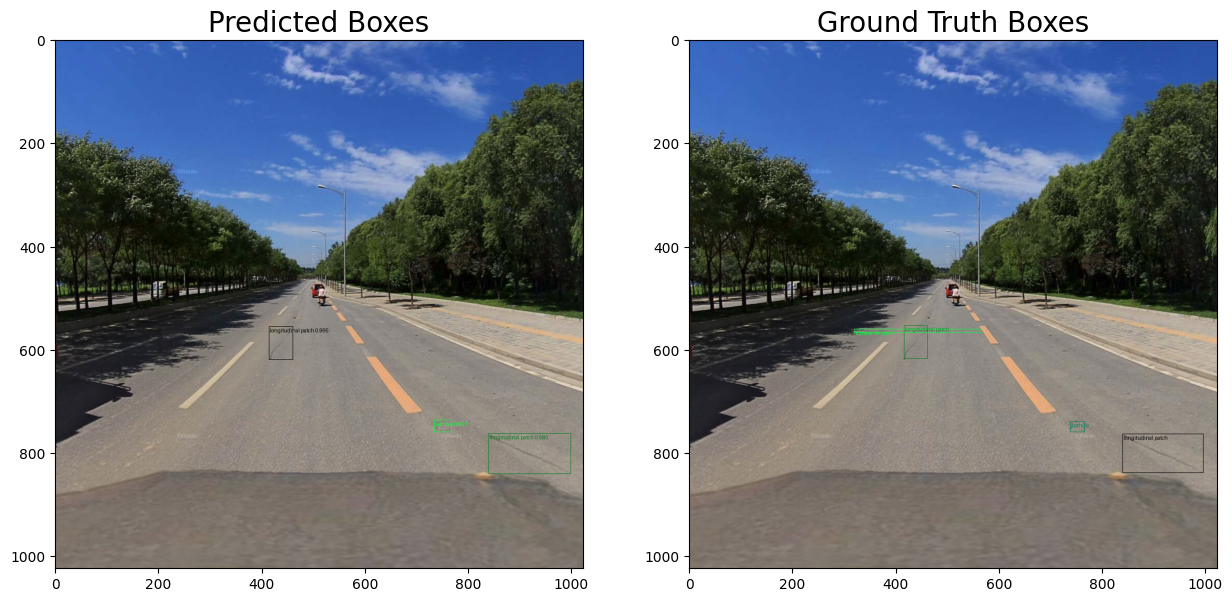

In [ ]:
# Example Prediction
image_id = 50

with open(DETECTIONS_PATH) as f:
    all_preds = json.load(f)
    
pred_box, pred_label, pred_score = get_one_example_prediction(image_id, all_preds)

# Getting image and target from dataset
print("Predicting...")
img_tensor, target = eval_dataset[image_id]

# Adjust to best threshold
threshold = 0.5
keep = pred_score >= threshold
boxes = pred_box[keep]
labels = pred_label[keep]
scores = pred_score[keep]

# Convert boxes from COCO format [x, y, w, h] to xyxy [xmin, ymin, xmax, ymax]
boxes[:, 2] = boxes[:, 0] + boxes[:, 2]
boxes[:, 3] = boxes[:, 1] + boxes[:, 3]

print("Visualizing Prediction...")
# Visualize predictions.
image_with_boxes = utils.draw_bounding_boxes(
    image=(img_tensor * 255).to(torch.uint8),
    boxes=boxes,
    labels=[f"{CLASSES[label.item()]} {score:.3f}" for label, score in zip(labels, scores)],
)

fig, ax = plt.subplots(1, 2, figsize=(15, 15))
ax[0].imshow(image_with_boxes.permute(1, 2, 0))

print("Visualizing GroundTruth...")
# Visualize predictions.
image_with_boxes = utils.draw_bounding_boxes(
    image=(img_tensor * 255).to(torch.uint8),
    boxes=target["boxes"],
    labels=[f"{CLASSES[label.item()]}" for label in target["labels"]],
)

# Colocar título nas imagens
ax[0].set_title("Predicted Boxes", fontsize=20)
ax[1].set_title("Ground Truth Boxes", fontsize=20)
ax[1].imshow(image_with_boxes.permute(1, 2, 0))
fig.savefig("pred_ground_truth.png")
plt.show()

# YOLOv11